In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import pipeline

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [74]:
df = pd.read_csv(r"C:\\Users\\User\\OneDrive\\Documents\\sentimenet analysis datasets\\Reviews.csv")

In [75]:

print(df.columns.tolist())

['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [76]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [77]:
df = df[['Score', 'Text']]

In [78]:
df = df[df['Score'] !=3]
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

In [79]:
df = df.drop(columns=['Score'])

In [80]:
print(df.shape)

(525814, 2)


In [81]:
df.head

<bound method NDFrame.head of                                                      Text  Sentiment
0       I have bought several of the Vitality canned d...          1
1       Product arrived labeled as Jumbo Salted Peanut...          0
2       This is a confection that has been around a fe...          1
3       If you are looking for the secret ingredient i...          0
4       Great taffy at a great price.  There was a wid...          1
...                                                   ...        ...
568449  Great for sesame chicken..this is a good if no...          1
568450  I'm disappointed with the flavor. The chocolat...          0
568451  These stars are small, so you can give 10-15 o...          1
568452  These are the BEST treats for training and rew...          1
568453  I am very satisfied ,product is as advertised,...          1

[525814 rows x 2 columns]>

In [82]:
df = df.sample(n=50000, random_state=42) #use only 50k row 

In [83]:
df = df.reset_index(drop=True) 

In [84]:
texts = df['Text'].dropna().astype(str)

In [85]:
print(df.shape)

(50000, 2)


In [86]:
print(df['Sentiment'].value_counts())

Sentiment
1    42147
0     7853
Name: count, dtype: int64


In [87]:
df.head()

,Text,Sentiment
0,This is a very high quality dog food with meat...,1
1,I love this cake mix and the other 3 mixes as ...,1
2,A nice strong brew. I am new to Keurig and hav...,1
3,I just found PB2 and PB2 with chocolate and I ...,1
4,Delightful mint tea as one would expect. Note ...,1


In [88]:
emote_pattern = r'((?:[:=;][oO\-]?[D\)\]\(\]/\\OpP]))' #this allow to remove emotes such as 
#:), :D, o_o etc

In [89]:
special_symbols_pattern = r'[^\w\s\.\,\!\?\'\"\-\@]' #removing special symbols that occur within the datasets

In [90]:
#understand how many types of emotes within the datasets, including emoticon and special symbols
emoji_counts = Counter()
emoticon_counts = Counter()
symbol_counts = Counter()
print("Scanning texts for emojis, emoticons, and symbols...")

Scanning texts for emojis, emoticons, and symbols...


In [91]:
for text in texts:
    extracting_emoji = [res['emoji'] for res in emoji.emoji_list(text)]
    emoji_counts.update(extracting_emoji)
    #emoji_list returns a lists of dicts with the emoji and its position
    emoticons = re.findall(emote_pattern, text)
    emoticon_counts.update(emoticons)
    #finding text that match emote_pattern
    clean_text = re.sub(emote_pattern, '', text)
    clean_text = emoji.replace_emoji(clean_text, replace='')
    #firstly, remove the emoticon and emojis from the text string temporary so that their component
    #symbols like :) or :D dont get counted as standalone symbols
    symbols = re.findall(special_symbols_pattern, clean_text)
    symbol_counts.update(symbols)

In [92]:
for char, count in emoji_counts.most_common(15):
    print(f"{char} : {count}")

® : 99


In [93]:
for char, count in emoticon_counts.most_common(15):
    print(f"{char} : {count}")

:/ : 1432
:) : 861
:-) : 170
:( : 112
;) : 100
:D : 53
=) : 45
;-) : 41
:-( : 36
:o) : 16
:P : 14
:-D : 9
=( : 8
=p : 8
=D : 6


In [94]:
for char, count in symbol_counts.most_common(20):
    print(f"{char} : {count}")

/ : 67972
> : 57836
< : 57700
) : 17644
( : 17262
: : 4699
& : 3992
$ : 3458
; : 2875
% : 2145
* : 2040
= : 1902
+ : 829
~ : 572
[ : 534
] : 526
# : 309
` : 67
^ : 31
} : 26


In [95]:
#elaborate what happenings

In [96]:
def final_clean_for_amazon(text):
    #remove html tags
    text = re.sub(r'<.*?>', ' ', text)
    #convert specific sentiment heavy emoticon to words
    #this ensures "good :)" stays positive even after stripping symbols
    emoticons_map = {
        r':\)': ' happyemoticon ',
        r':-\)': ' happyemoticon ',
        r':D': ' happyemoticon ',
        r':\(': ' sademoticon ',
        r':-\(': ' sademoticon ',
        r':/': ' skepticalemoticon '
    }
    for pattern, word in emoticons_map.items():
        text = re.sub(pattern, word, text)

        #handle the '&' and other entities
        text = re.sub(r'&[\w#]+;', ' ', text)
        #remove the leftover symbols/numbers but keep our new emoticon words
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        #lowercase and remove extra whitespace
        text = text.lower().strip()
        text = re.sub(r'\s+', ' ', text)
        return text

In [97]:
sample = "The coffee was great! :) <br /> But the price was too high $$. :/"
print(final_clean_for_amazon(sample))

the coffee was great happyemoticon but the price was too high


In [98]:
df['CleanedText'] = df['Text'].apply(final_clean_for_amazon)

In [99]:
print(df[['Text', 'CleanedText']].head())

                                                Text  \
0  This is a very high quality dog food with meat...   
1  I love this cake mix and the other 3 mixes as ...   
2  A nice strong brew. I am new to Keurig and hav...   
3  I just found PB2 and PB2 with chocolate and I ...   
4  Delightful mint tea as one would expect. Note ...   

                                         CleanedText  
0  this is a very high quality dog food with meat...  
1  i love this cake mix and the other mixes as we...  
2  a nice strong brew i am new to keurig and have...  
3  i just found pb and pb with chocolate and i am...  
4  delightful mint tea as one would expect note t...  


In [100]:
sample_check = df[df['Text'].str.contains(r':\)', na=False)].head(2)

for i, row in sample_check.iterrows():
    print(f"ORIGINAL: {row['Text']}")
    print(f"CLEANED : {row['CleanedText']}")
    print("-" * 30)

ORIGINAL: I search for this candy everywhere,candy stores no luck.i got them as a Christmas gift :) for my boyfriend. .he loved it
CLEANED : i search for this candy everywherecandy stores no lucki got them as a christmas gift happyemoticon for my boyfriend he loved it
------------------------------
ORIGINAL: I just recently purchased a keurig coffee maker,,,,and have tried almost all of the different coffee flavors and brands of K-Cups,,,<br /><br />This to me is the all time BEST,,,,with Eggnog being a close second,,,,<br /><br />the pumpkin spice with a little sugar and cream is superb beyond belief :)<br /><br />Bonney from Cape Cod,, Massachusettes
CLEANED : i just recently purchased a keurig coffee makerand have tried almost all of the different coffee flavors and brands of kcups this to me is the all time bestwith eggnog being a close second the pumpkin spice with a little sugar and cream is superb beyond belief happyemoticon bonney from cape cod massachusettes
------------------

In [101]:
contains_html = df['CleanedText'].str.contains('<|>').sum()
print(f"Number of rows still containing HTML brackets: {contains_html}")

contains_symbols = df['CleanedText'].str.contains(r'[^a-zA-Z\s]').sum()
print(f"Number of rows still containing symbols/numbers: {contains_symbols}")

Number of rows still containing HTML brackets: 0
Number of rows still containing symbols/numbers: 0


In [102]:
# max_features=5000: we keep only the top 5,000 most important words/phrases to prevent your computer's RAM from crashing.
# ngram_range=(1, 2): this is crucial as it counts single words ("good") and two word pairs ("not good", "very happy").
tfidataframe = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
print("Converting text to numbers")

Converting text to numbers


In [103]:
#transform the text into 'X' matrix which is the features
X = tfidataframe.fit_transform(df['CleanedText'])

In [104]:
y = df['Sentiment']

In [105]:
print(f"Success! X (Features) Shape: {X.shape}")
print(f"y (Labels) Shape: {y.shape}")

Success! X (Features) Shape: (50000, 5000)
y (Labels) Shape: (50000,)


In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 40000 samples
Testing set size: 10000 samples


In [124]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

predictions = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.9282
              precision    recall  f1-score   support

           0       0.90      0.60      0.72      1542
           1       0.93      0.99      0.96      8458

    accuracy                           0.93     10000
   macro avg       0.91      0.80      0.84     10000
weighted avg       0.93      0.93      0.92     10000



In [ ]:
# CONFUSION MATRIX BREAKDOWN

# True Negative  = 932  → correctly predicted NEGATIVE reviews
# False Positive = 610  → predicted POSITIVE but actually NEGATIVE
# False Negative = 108  → predicted NEGATIVE but actually POSITIVE  
# True Positive  = 8350 → correctly predicted POSITIVE reviews

# INSIGHT 1: Model is very good at detecting POSITIVE reviews (8350 correct!)
# INSIGHT 2: Model struggles more with NEGATIVE reviews (610 wrong)
# INSIGHT 3: This is because dataset has WAY more positive reviews than negative
# This is called CLASS IMBALANCE — same issue we saw in Titanic!

# INSIGHT 4: 92.82% accuracy is excellent for a TF-IDF + Logistic Regression model

In [125]:

predictions = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.9282
              precision    recall  f1-score   support

           0       0.90      0.60      0.72      1542
           1       0.93      0.99      0.96      8458

    accuracy                           0.93     10000
   macro avg       0.91      0.80      0.84     10000
weighted avg       0.93      0.93      0.92     10000



In [126]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

predictions = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.9282
              precision    recall  f1-score   support

           0       0.90      0.60      0.72      1542
           1       0.93      0.99      0.96      8458

    accuracy                           0.93     10000
   macro avg       0.91      0.80      0.84     10000
weighted avg       0.93      0.93      0.92     10000



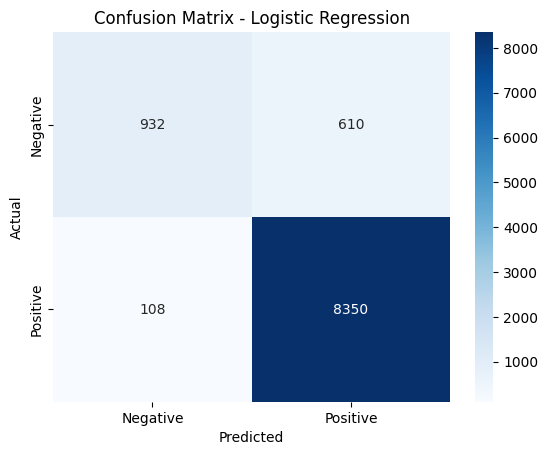

In [127]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [128]:
#load pretrained sentiment analysis model
print("Loading HuggingFace model...")
classifier = pipeline("sentiment-analysis")

sample_reviews = [
    "This product is absolutely amazing!",
    "Terrible quality, total waste of money.",
    "It was okay, nothing special.",
    "Best dog food I have ever bought!",
    "I will never buy this again."
]

for review in sample_reviews:
    result = classifier(review)
    print(f"Review: {review}")
    print(f"Sentiment: {result[0]['label']} | Confidence: {result[0]['score']:.2f}")
    print()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading HuggingFace model...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7559.14it/s]


Review: This product is absolutely amazing!
Sentiment: POSITIVE | Confidence: 1.00

Review: Terrible quality, total waste of money.
Sentiment: NEGATIVE | Confidence: 1.00

Review: It was okay, nothing special.
Sentiment: NEGATIVE | Confidence: 0.98

Review: Best dog food I have ever bought!
Sentiment: POSITIVE | Confidence: 1.00

Review: I will never buy this again.
Sentiment: NEGATIVE | Confidence: 0.97



In [ ]:
#now using the model to predict on 100 real reviews from our dataset to compare with our logistic regression results(originally 100 reviews is too small, let's try 500)
sample = df.sample(n=500, random_state=42)

hf_predictions = []
for review in sample['CleanedText']:
    result = classifier(review[:512])  #BERT max 512 chars
    label = 1 if result[0]['label'] == 'POSITIVE' else 0
    hf_predictions.append(label)

hf_accuracy = accuracy_score(sample['Sentiment'], hf_predictions)
print(f"HuggingFace Accuracy: {hf_accuracy:.2%}")#huggingfaceisaroundon83%one100sample
print(f"Logistic Regression Accuracy: 92.82%")

HuggingFace Accuracy: 78.40%
Logistic Regression Accuracy: 92.82%


In [130]:
#considering how bad the performance of HuggingFace i try to use original text instead of cleaned text to see if it can capture the sentiment better
sample = df.sample(n=100, random_state=42)

hf_predictions = []
for review in sample['Text']:  #raw text this time!
    result = classifier(review[:512])
    label = 1 if result[0]['label'] == 'POSITIVE' else 0
    hf_predictions.append(label)

hf_accuracy = accuracy_score(sample['Sentiment'], hf_predictions)
print(f"HuggingFace Accuracy (raw text): {hf_accuracy:.2%}")

HuggingFace Accuracy (raw text): 83.00%


In [132]:
# WHY LR STILL WINS ON THIS SPECIFIC DATASET:

# 1. CLASS IMBALANCE
# 85% of reviews are positive, 15% negative
# LR exploits this pattern aggressively
# HuggingFace is more "fair" and balanced

# 2. DOMAIN SPECIFICITY
# DistilBERT is a general purpose model
# LR was trained specifically on Amazon food reviews
# Specific always beats general on narrow tasks

# 3. SAMPLE SIZE
# HuggingFace tested on only 100 reviews
# LR tested on 2000 reviews → more reliable number

# CONCLUSION:
# Bigger ≠ always better
# The right tool depends on your data and use case!